# 🩺 Espace Médecin — Coding Week 2026
**Membre 2** | Obesity Risk Estimation | UCI Dataset

In [1]:
!pip install lightgbm catboost xgboost shap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:000:00:0100:01


In [9]:
# ── IMPORTS ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib
import os
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from datetime import datetime
from google.colab import files, drive

print('✅ Imports OK')

✅ Imports OK


In [10]:
# ── MOUNT GOOGLE DRIVE ──
drive.mount('/content/drive')

# ⚠️ Modifie ce chemin vers ton dossier projet sur Drive
PROJECT_PATH = '/content/drive/MyDrive/Coding_week_Groupe-17'

DATA_PATH    = f'{PROJECT_PATH}/data'
OUTPUTS_PATH = f'{PROJECT_PATH}/outputs'

print(f'📁 Projet : {PROJECT_PATH}')
print(f'📊 Data   : {DATA_PATH}')
print(f'🤖 Models : {OUTPUTS_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Projet : /content/drive/MyDrive/Coding_week_Groupe-17
📊 Data   : /content/drive/MyDrive/Coding_week_Groupe-17/data
🤖 Models : /content/drive/MyDrive/Coding_week_Groupe-17/outputs


In [11]:
# ── CONSTANTES ────────────────────────────────────────────────
CLASSES = [
    'Insufficient_Weight', 'Normal_Weight',
    'Obesity_Type_I',      'Obesity_Type_II',
    'Obesity_Type_III',    'Overweight_Level_I',
    'Overweight_Level_II'
]

CLASS_COLORS = [
    '#3B82F6', '#10B981', '#F59E0B',
    '#F97316', '#EF4444', '#8B5CF6', '#EC4899'
]

CLASS_EMOJIS = ['🔵', '🟢', '🟡', '🟠', '🔴', '🟣', '🩷']

print('✅ Constantes OK')

✅ Constantes OK


In [12]:
# ── CHARGEMENT DU MODÈLE ──────────────────────────────────────
def load_best_model():
    for name in ['lightgbm', 'xgboost', 'catboost', 'random_forest']:
        path = f'{OUTPUTS_PATH}/{name}.pkl'
        if os.path.exists(path):
            obj = joblib.load(path)
            if isinstance(obj, dict) and 'model' in obj:
                obj = obj['model']
            print(f'✅ Modèle chargé : {name} ({type(obj).__name__})')
            return obj, name
    print('❌ Aucun modèle trouvé dans outputs/')
    return None, None

model, model_name = load_best_model()

✅ Modèle chargé : lightgbm (LGBMClassifier)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [13]:
# ── CHARGEMENT DES DONNÉES ────────────────────────────────────
X_test = pd.read_csv(f'{DATA_PATH}/X_test.csv')
y_test = pd.read_csv(f'{DATA_PATH}/y_test.csv').squeeze()

# Patients (créé si absent)
patients_path = f'{DATA_PATH}/patients.csv'
if os.path.exists(patients_path):
    patients_df = pd.read_csv(patients_path)
else:
    patients_df = pd.DataFrame(columns=['id','nom','prenom','age','genre','email'])
    patients_df.to_csv(patients_path, index=False)

# Suivi (créé si absent)
suivi_path = f'{DATA_PATH}/suivi.csv'
if os.path.exists(suivi_path):
    suivi_df = pd.read_csv(suivi_path)
else:
    suivi_df = pd.DataFrame(columns=[
        'patient_id','date','medecin',
        'prediction','confidence','imc','recommandations'
    ])
    suivi_df.to_csv(suivi_path, index=False)

print(f'✅ X_test : {X_test.shape}')
print(f'✅ Patients : {len(patients_df)} enregistrés')
print(f'✅ Suivi : {len(suivi_df)} consultations')

✅ X_test : (423, 16)
✅ Patients : 0 enregistrés
✅ Suivi : 0 consultations


---
## 👥 ÉTAPE 1 — Liste des patients

In [14]:
# ── AFFICHAGE DES PATIENTS ────────────────────────────────────
if patients_df.empty:
    display(HTML("""
    <div style='background:#FEF3C7; border:1px solid #F59E0B;
                border-radius:10px; padding:15px; font-family:sans-serif;'>
        ⚠️ <b>Aucun patient enregistré</b><br>
        Le fichier patients.csv sera rempli par Membre 1.<br>
        Tu peux quand même saisir les données manuellement ci-dessous.
    </div>
    """))
else:
    display(HTML('<h3>👥 Liste des patients</h3>'))
    styled = patients_df.style.set_properties(**{
        'background-color': '#F8FAFC',
        'border': '1px solid #E2E8F0',
        'padding': '8px'
    })
    display(styled)

---
## 📋 ÉTAPE 2 — Saisie des données patient

In [ ]:
# ── FORMULAIRE DE SAISIE ──────────────────────────────────────
display(HTML('<h3>📋 Données du patient</h3>'))

style  = {'description_width': '220px'}
layout = widgets.Layout(width='420px')

# Infos patient
w_pid    = widgets.Text(description='ID Patient :',    value='P001',      style=style, layout=layout)
w_name   = widgets.Text(description='Nom complet :',   value='',          style=style, layout=layout)
w_doc    = widgets.Text(description='Médecin :',       value='Dr. ',      style=style, layout=layout)

# Données cliniques
w_gender = widgets.Dropdown(description='Genre :',             options=['Homme','Femme'],                          style=style, layout=layout)
w_age    = widgets.IntSlider(description='Âge :',              min=10, max=80,  value=30,                          style=style, layout=layout)
w_height = widgets.FloatSlider(description='Taille (m) :',     min=1.40, max=2.00, value=1.70, step=0.01,          style=style, layout=layout)
w_weight = widgets.FloatSlider(description='Poids (kg) :',     min=30, max=180,   value=75,    step=0.5,           style=style, layout=layout)
w_hist   = widgets.Dropdown(description='Antécédents familiaux :', options=['Oui','Non'],                          style=style, layout=layout)
w_favc   = widgets.Dropdown(description='Aliments hypercaloriques (FAVC) :', options=['Oui','Non'],                style=style, layout=layout)
w_fcvc   = widgets.IntSlider(description='Fréquence légumes (FCVC) :', min=1, max=3, value=2,                      style=style, layout=layout)
w_ncp    = widgets.IntSlider(description='Repas/jour (NCP) :',  min=1, max=4, value=3,                            style=style, layout=layout)
w_caec   = widgets.Dropdown(description='Grignotage (CAEC) :',  options=['Non','Parfois','Fréquemment','Toujours'],style=style, layout=layout)
w_ch2o   = widgets.IntSlider(description='Eau/jour L (CH2O) :', min=1, max=3, value=2,                            style=style, layout=layout)
w_smoke  = widgets.Dropdown(description='Fumeur :',             options=['Non','Oui'],                            style=style, layout=layout)
w_scc    = widgets.Dropdown(description='Surveille calories :',  options=['Non','Oui'],                           style=style, layout=layout)
w_faf    = widgets.IntSlider(description='Activité physique (j/sem) :', min=0, max=3, value=1,                     style=style, layout=layout)
w_tue    = widgets.IntSlider(description='Temps écran (h/j) :', min=0, max=2, value=1,                            style=style, layout=layout)
w_calc   = widgets.Dropdown(description='Alcool (CALC) :',      options=['Non','Parfois','Fréquemment','Toujours'],style=style, layout=layout)
w_mtrans = widgets.Dropdown(description='Transport :',          options=['Vélo','Moto','Voiture','Transport en commun','Marche'], style=style, layout=layout)

# IMC en temps réel
imc_out = widgets.Output()

def update_imc(*args):
    imc = w_weight.value / (w_height.value ** 2)
    with imc_out:
        clear_output(wait=True)
        if imc < 18.5:   cat, col = 'Insuffisance pondérale', '#3B82F6'
        elif imc < 25:   cat, col = 'Poids normal',           '#10B981'
        elif imc < 30:   cat, col = 'Surpoids',               '#F59E0B'
        elif imc < 35:   cat, col = 'Obésité modérée',        '#F97316'
        else:            cat, col = 'Obésité sévère',         '#EF4444'
        display(HTML(f"""
        <div style='background:{col}22; border:2px solid {col}; border-radius:10px;
                    padding:10px; margin:5px 0; font-family:sans-serif; width:400px;'>
            <b style='color:{col}'>IMC : {imc:.1f}</b> — {cat}
        </div>
        """))

w_height.observe(update_imc, names='value')
w_weight.observe(update_imc, names='value')

# Affichage en sections
display(HTML('<b>👤 Informations patient</b>'))
display(w_pid, w_name, w_doc)
display(HTML('<br><b>🧬 Données personnelles</b>'))
display(w_gender, w_age, w_height, w_weight, imc_out)
display(HTML('<br><b>🍽️ Habitudes alimentaires</b>'))
display(w_hist, w_favc, w_fcvc, w_ncp, w_caec, w_ch2o, w_calc)
display(HTML('<br><b>🏃 Mode de vie</b>'))
display(w_smoke, w_scc, w_faf, w_tue, w_mtrans)

update_imc()

Text(value='P001', description='ID Patient :', layout=Layout(width='420px'), style=DescriptionStyle(descriptio…

Text(value='', description='Nom complet :', layout=Layout(width='420px'), style=DescriptionStyle(description_w…

Text(value='Dr. ', description='Médecin :', layout=Layout(width='420px'), style=DescriptionStyle(description_w…

Dropdown(description='Genre :', layout=Layout(width='420px'), options=('Homme', 'Femme'), style=DescriptionSty…

IntSlider(value=30, description='Âge :', layout=Layout(width='420px'), max=80, min=10, style=SliderStyle(descr…

...

Dropdown(description='Fumeur :', layout=Layout(width='420px'), options=('Non', 'Oui'), style=DescriptionStyle(…

Dropdown(description='Surveille calories :', layout=Layout(width='420px'), options=('Non', 'Oui'), style=Descr…

IntSlider(value=1, description='Activité physique (j/sem) :', layout=Layout(width='420px'), max=3, style=Slide…

IntSlider(value=1, description='Temps écran (h/j) :', layout=Layout(width='420px'), max=2, style=SliderStyle(d…

Dropdown(description='Transport :', layout=Layout(width='420px'), options=('Vélo', 'Moto', 'Voiture', 'Transpo…

---
## 🔮 ÉTAPE 3 — Prédiction + SHAP

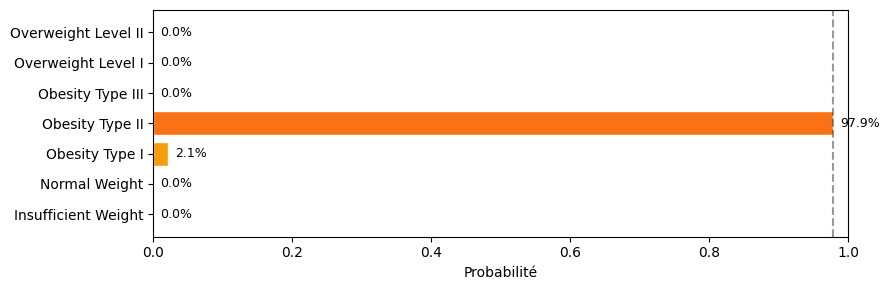

⚠️ SHAP non disponible : The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


In [16]:
# ── FONCTION DE PRÉDICTION ────────────────────────────────────
def build_input():
    caec_map  = {'Non': 0, 'Parfois': 1, 'Fréquemment': 2, 'Toujours': 3}
    calc_map  = {'Non': 0, 'Parfois': 1, 'Fréquemment': 2, 'Toujours': 3}
    trans_map = {'Vélo': 0, 'Moto': 1, 'Voiture': 2, 'Transport en commun': 3, 'Marche': 4}
    return pd.DataFrame([{
        'Gender':                         1 if w_gender.value == 'Homme' else 0,
        'Age':                            w_age.value,
        'Height':                         w_height.value,
        'Weight':                         w_weight.value,
        'family_history_with_overweight': 1 if w_hist.value == 'Oui' else 0,
        'FAVC':                           1 if w_favc.value == 'Oui' else 0,
        'FCVC':                           w_fcvc.value,
        'NCP':                            w_ncp.value,
        'CAEC':                           caec_map[w_caec.value],
        'SMOKE':                          1 if w_smoke.value == 'Oui' else 0,
        'CH2O':                           w_ch2o.value,
        'SCC':                            1 if w_scc.value == 'Oui' else 0,
        'FAF':                            w_faf.value,
        'TUE':                            w_tue.value,
        'CALC':                           calc_map[w_calc.value],
        'MTRANS':                         trans_map[w_mtrans.value],
    }])


def predict_and_display():
    if model is None:
        print('❌ Modèle non chargé !')
        return None, None, None

    df = build_input()
    imc = w_weight.value / (w_height.value ** 2)

    # Prédiction
    raw   = model.predict(df)
    pred  = int(np.array(raw).flatten()[0])
    proba = model.predict_proba(df)[0]
    label = CLASSES[pred]
    conf  = proba.max() * 100
    color = CLASS_COLORS[pred]
    emoji = CLASS_EMOJIS[pred]

    # ── Résultat principal ────────────────────────────────────
    display(HTML(f"""
    <div style='background:{color}22; border:3px solid {color}; border-radius:16px;
                padding:25px; text-align:center; font-family:sans-serif; margin:15px 0;'>
        <div style='font-size:50px'>{emoji}</div>
        <h2 style='color:{color}; margin:10px 0;'>{label.replace('_',' ')}</h2>
        <h3 style='color:#374151;'>Confiance : {conf:.1f}%</h3>
        <p style='color:#6B7280;'>IMC : <b>{imc:.1f}</b></p>
    </div>
    """))

    # ── Probabilités par classe ───────────────────────────────
    display(HTML('<h4>📊 Probabilités par classe</h4>'))
    fig, ax = plt.subplots(figsize=(9, 3))
    bars = ax.barh([c.replace('_',' ') for c in CLASSES], proba,
                   color=CLASS_COLORS, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probabilité')
    ax.axvline(proba[pred], color='black', linestyle='--', alpha=0.4)
    for bar, p in zip(bars, proba):
        ax.text(p + 0.01, bar.get_y() + bar.get_height()/2,
                f'{p*100:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── SHAP ──────────────────────────────────────────────────
    display(HTML('<h4>🔍 Explication SHAP — Facteurs influençant la prédiction</h4>'))
    try:
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(df)

        if isinstance(shap_values, list):
            sv = shap_values[pred][0]
        else:
            sv = shap_values[0]

        features   = df.columns.tolist()
        sorted_idx = np.argsort(np.abs(sv))[-10:]
        colors_shap = ['#EF4444' if sv[i] > 0 else '#3B82F6' for i in sorted_idx]

        fig2, ax2 = plt.subplots(figsize=(9, 4))
        ax2.barh([features[i] for i in sorted_idx],
                 [sv[i] for i in sorted_idx],
                 color=colors_shap)
        ax2.axvline(0, color='black', linewidth=0.8)
        ax2.set_title('SHAP — Top 10 facteurs (🔴 augmente le risque / 🔵 le diminue)')
        ax2.set_xlabel('Impact SHAP')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'⚠️ SHAP non disponible : {e}')

    return df, label, conf, imc


# ── LANCER LA PRÉDICTION ──────────────────────────────────────
result = predict_and_display()

---
## 📝 ÉTAPE 4 — Recommandations et sauvegarde

In [ ]:
# ── RECOMMANDATIONS ───────────────────────────────────────────
display(HTML('<h3>📝 Recommandations médicales</h3>'))

TEMPLATES = [
    'Augmenter l\'activité physique à 30 min/jour minimum.',
    'Réduire la consommation d\'aliments ultra-transformés.',
    'Consulter un nutritionniste pour un plan alimentaire adapté.',
    'Surveiller l\'IMC chaque mois.',
    'Réduire la consommation d\'alcool.',
    'Augmenter la consommation d\'eau à 2L/jour.',
    'Favoriser les légumes et fibres à chaque repas.',
    'Éviter les grignotages entre les repas.',
]

display(HTML('<b>✅ Modèles rapides (cocher) :</b>'))
checkboxes = [widgets.Checkbox(value=False, description=t,
              layout=widgets.Layout(width='600px')) for t in TEMPLATES]
for cb in checkboxes:
    display(cb)

display(HTML('<br><b>✏️ Recommandations personnalisées :</b>'))
w_reco = widgets.Textarea(
    placeholder='Saisir les recommandations pour ce patient...',
    layout=widgets.Layout(width='600px', height='120px')
)
display(w_reco)

In [ ]:
# ── SAUVEGARDE ────────────────────────────────────────────────
def save_consultation():
    # Récupérer les templates cochés
    selected = [cb.description for cb in checkboxes if cb.value]
    all_recos = selected + ([w_reco.value] if w_reco.value.strip() else [])

    if not all_recos:
        display(HTML("<p style='color:#EF4444'>⚠️ Aucune recommandation saisie !</p>"))
        return

    if result is None:
        display(HTML("<p style='color:#EF4444'>⚠️ Lance d'abord la prédiction (Étape 3) !</p>"))
        return

    df_input, label, conf, imc = result

    record = {
        'patient_id':      w_pid.value,
        'nom':             w_name.value,
        'date':            datetime.now().strftime('%Y-%m-%d %H:%M'),
        'medecin':         w_doc.value,
        'prediction':      label,
        'confidence':      f'{conf:.1f}%',
        'imc':             round(w_weight.value / (w_height.value ** 2), 1),
        'recommandations': ' | '.join(all_recos)
    }

    # Charger + ajouter + sauvegarder
    suivi_df = pd.read_csv(suivi_path) if os.path.exists(suivi_path) else pd.DataFrame()
    suivi_df = pd.concat([suivi_df, pd.DataFrame([record])], ignore_index=True)
    suivi_df.to_csv(suivi_path, index=False)

    display(HTML(f"""
    <div style='background:#D1FAE5; border:2px solid #10B981; border-radius:12px;
                padding:15px; font-family:sans-serif; margin:10px 0;'>
        ✅ <b>Consultation sauvegardée !</b><br>
        Patient : {w_pid.value} — {w_name.value}<br>
        Prédiction : {label.replace('_',' ')} ({conf:.1f}%)<br>
        Fichier : {suivi_path}
    </div>
    """))

    # Afficher le suivi mis à jour
    display(HTML('<h4>📂 Suivi mis à jour :</h4>'))
    display(suivi_df.tail(5))


btn_save = widgets.Button(
    description='💾 Sauvegarder la consultation',
    button_style='success',
    layout=widgets.Layout(width='300px', height='40px')
)
btn_save.on_click(lambda b: save_consultation())
display(btn_save)

---
## 📂 ÉTAPE 5 — Historique des consultations

In [ ]:
# ── HISTORIQUE ────────────────────────────────────────────────
display(HTML('<h3>📂 Historique des consultations</h3>'))

if os.path.exists(suivi_path):
    suivi_hist = pd.read_csv(suivi_path)
    if suivi_hist.empty:
        display(HTML('<p>Aucune consultation enregistrée.</p>'))
    else:
        display(suivi_hist.sort_values('date', ascending=False))

        # Stats
        display(HTML('<h4>📊 Distribution des prédictions</h4>'))
        counts = suivi_hist['prediction'].value_counts()
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar([c.replace('_',' ') for c in counts.index], counts.values,
               color=[CLASS_COLORS[CLASSES.index(c)] if c in CLASSES else '#94A3B8'
                      for c in counts.index])
        ax.set_ylabel('Nombre de patients')
        ax.set_title('Distribution des niveaux d\'obésité — Consultations')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
else:
    display(HTML('<p>Aucune consultation enregistrée.</p>'))

In [ ]:
# ── EXPORT CSV ────────────────────────────────────────────────
if os.path.exists(suivi_path):
    files.download(suivi_path)
    print('📥 Téléchargement du suivi.csv lancé !')